# Clinical Telemetry Analysis: Treatment Response and Laboratory Trends

### Initial Treatment Phase — Chemotherapy & Amivantamab


# Project Overview

This project analyzes longitudinal clinical laboratory data across different treatment phases, including chemotherapy, amivantamab induction and maintenance, pre-medication, supportive interventions, and documented clinical symptoms.

The aim is to understand how key laboratory parameters changed over time and how those changes aligned with treatment events and clinical observations.


# Objective

The main objective of this analysis is to:

- Track changes in **WBC, neutrophils, platelets, and creatinine** across the treatment timeline.
- Compare laboratory values with their selected reference ranges.
- Identify periods of **decline, recovery, and rebound** in blood counts.
- Examine the relationship between laboratory changes and **chemotherapy, amivantamab, steroid pre-medication, G-CSF, and platelet support**.
- Connect laboratory measurements with the **clinical symptoms and events documented on the same dates**.
- Identify important patterns that can generate questions for the next stage of clinical analysis.

---


# # Dataset

The analysis uses the `Clinical_Telemetry_Labs_Enriched.xlsx` file and the **Clinical Telemetry Data** worksheet.

The dataset contains **14 clinical observations and 27 columns**.

## Dataset Columns

| Column | Description |
|---|---|
| `Date` | Date of clinical/laboratory observation |
| `Clinical Event / Phase` | Specific treatment or clinical event |
| `Clinical Phase Category` | Grouped clinical phase used for analysis |
| `Chemotherapy` | Chemotherapy administered during the phase |
| `Targeted Therapy` | Targeted treatment documented |
| `Pre-Medication` | Pre-medications given around treatment |
| `Platelets Support` | Whether platelet support was documented |
| `G-CSF Intervention` | Whether G-CSF intervention was documented |
| `Hb (g/dL)` | Hemoglobin measurement |
| `RBC (x10^6/uL)` | Red blood cell count |
| `WBC (/uL)` | White blood cell count |
| `Neutrophils (%)` | Percentage of neutrophils |
| `ANC (/uL)` | Absolute neutrophil count |
| `Lymphocytes (%)` | Percentage of lymphocytes |
| `Platelets (x10^3/uL)` | Platelet count |
| `Creatinine (mg/dL)` | Creatinine measurement |
| `BUN (mg/dL)` | Blood urea nitrogen |
| `eGFR (mL/min)` | Estimated glomerular filtration rate |
| `SGOT/AST (U/L)` | AST measurement |
| `SGPT/ALT (U/L)` | ALT measurement |
| `Albumin (g/dL)` | Albumin measurement |
| `Bilirubin (mg/dL)` | Bilirubin measurement |
| `Na (mEq/L)` | Sodium |
| `K (mEq/L)` | Potassium |
| `Cl (mEq/L)` | Chloride |
| `PSA (ng/mL)` | PSA measurement |
| `Clinical Symptoms / Notes` | Symptoms, observations and clinical notes recorded for the date |

---

# Clinical Events Covered

The timeline includes:

1. Pre-diagnosis Baseline
2. Chemo #1 Day 1
3. Post Chemo #1 (Day +7)
4. Chemo #2 Day 1
5. Chemo #3 + Amivantamab Induction #1
6. Amivantamab Induction #2
7. Amivantamab Induction #3
8. Chemo #4 + Amivantamab Induction #4
9. Inter-cycle Mid Check
10. Chemo #5 + Amivantamab Maintenance #1
11. Chemo #6 + Amivantamab Maintenance #2
12. Urological Evaluation (USG KUB)
13. Amivantamab Maintenance #3
14. Chemo #7

---


In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set (color_codes = True)
import warnings 
warnings.filterwarnings('ignore')


In [52]:
# import os
os.getcwd()
os.chdir('C:\\Users\\nidhi\\Downloads')
os.getcwd()

'C:\\Users\\nidhi\\Downloads'

In [53]:

file_path = 'Clinical_Telemetry_Labs_Enriched.xlsx'

df = pd.read_excel(
    file_path,
    sheet_name='Clinical Telemetry Data')

df['Date_dt'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

df.head()

,Date,Clinical Event / Phase,Clinical Phase Category,Chemotherapy,Targeted Therapy,Pre-Medication,Platelets Support,G-CSF Intervention,Hb (g/dL),RBC (x10^6/uL),...,SGOT/AST (U/L),SGPT/ALT (U/L),Albumin (g/dL),Bilirubin (mg/dL),Na (mEq/L),K (mEq/L),Cl (mEq/L),PSA (ng/mL),Clinical Symptoms / Notes,Date_dt
0,2025-11-06,Pre-diagnosis Baseline,Baseline,NaN,NaN,NaN,False,False,14.8,4.6,...,56.0,40.0,4.6,0.7,139.0,4.3,101.0,0.4,"Pre-treatment baseline; silent presentation, p...",2025-11-06
1,2025-11-26,Chemo #1 Day 1,Pre-Chemo Baseline,"Pemetrexed, Carboplatin",NaN,NaN,False,False,14.1,4.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cycle 1 Chemo baseline: normal marrow reserve ...,2025-11-26
2,2025-12-03,Post Chemo #1 (Day +7),Post-Chemo Reaction,NaN,NaN,NaN,False,True,12.3,3.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Post-Chemo Day +7 reaction: conjunctival eryth...,2025-12-03
3,2025-12-17,Chemo #2 Day 1,Pre-Chemo Clearance,"Pemetrexed, Carboplatin",NaN,NaN,False,True,14.1,4.4,...,25.0,30.0,3.4,0.6,NaN,NaN,NaN,NaN,Pre-Cycle 2 clearance: counts rebounded well (...,2025-12-17
4,2026-01-08,Chemo #3 + Amivantamab Ind #1,Steroid Neutrophil Surge,"Pemetrexed, Carboplatin",Amivantamab,Decamax 16mg (2d),False,True,12.3,3.8,...,35.0,31.0,3.4,1.0,NaN,NaN,NaN,NaN,Steroid Surge Phase (Decamax 8mg): profound de...,2026-01-08


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       14 non-null     object        
 1   Clinical Event / Phase     14 non-null     object        
 2   Clinical Phase Category    14 non-null     object        
 3   Chemotherapy               7 non-null      object        
 4   Targeted Therapy           7 non-null      object        
 5   Pre-Medication             7 non-null      object        
 6   Platelets Support          14 non-null     bool          
 7   G-CSF Intervention         14 non-null     bool          
 8   Hb (g/dL)                  13 non-null     float64       
 9   RBC (x10^6/uL)             13 non-null     float64       
 10  WBC (/uL)                  12 non-null     float64       
 11  Neutrophils (%)            13 non-null     float64       
 12  ANC (/uL) 

In [55]:
df.shape

(14, 28)

In [56]:
df.columns


Index(['Date', 'Clinical Event / Phase', 'Clinical Phase Category',
       'Chemotherapy', 'Targeted Therapy', 'Pre-Medication',
       'Platelets Support', 'G-CSF Intervention', 'Hb (g/dL)',
       'RBC (x10^6/uL)', 'WBC (/uL)', 'Neutrophils (%)', 'ANC (/uL)',
       'Lymphocytes (%)', 'Platelets (x10^3/uL)', 'Creatinine (mg/dL)',
       'BUN (mg/dL)', 'eGFR (mL/min)', 'SGOT/AST (U/L)', 'SGPT/ALT (U/L)',
       'Albumin (g/dL)', 'Bilirubin (mg/dL)', 'Na (mEq/L)', 'K (mEq/L)',
       'Cl (mEq/L)', 'PSA (ng/mL)', 'Clinical Symptoms / Notes', 'Date_dt'],
      dtype='object')

In [57]:
Clinical_table=df[['Date', 'Clinical Event / Phase', 'Clinical Phase Category','Clinical Symptoms / Notes',
                   'Platelets Support', 'G-CSF Intervention']].copy()
Clinical_table

,Date,Clinical Event / Phase,Clinical Phase Category,Clinical Symptoms / Notes,Platelets Support,G-CSF Intervention
0,2025-11-06,Pre-diagnosis Baseline,Baseline,"Pre-treatment baseline; silent presentation, p...",False,False
1,2025-11-26,Chemo #1 Day 1,Pre-Chemo Baseline,Cycle 1 Chemo baseline: normal marrow reserve ...,False,False
2,2025-12-03,Post Chemo #1 (Day +7),Post-Chemo Reaction,Post-Chemo Day +7 reaction: conjunctival eryth...,False,True
3,2025-12-17,Chemo #2 Day 1,Pre-Chemo Clearance,Pre-Cycle 2 clearance: counts rebounded well (...,False,True
4,2026-01-08,Chemo #3 + Amivantamab Ind #1,Steroid Neutrophil Surge,Steroid Surge Phase (Decamax 8mg): profound de...,False,True
5,2026-01-16,Amivantamab Ind #2,Chemo Thrombocyte Nadir,Chemo Nadir Phase (Day +8 post-chemo): myelosu...,False,False
6,2026-01-23,Amivantamab Ind #3,Targeted Mucocutaneous Nadir,Targeted Nadir & Cutaneous Phase: leukopenia (...,True,False
7,2026-01-30,Chemo #4 + Amivantamab Ind #4,Steroid & Rebound Surge,Steroid Surge & Rebound Phase: post-booster re...,False,True
8,2026-02-13,Inter-cycle Mid Check,Deep Chemo Leukocyte Nadir,Deep Chemo Nadir Phase (Mid-cycle Day +14): se...,False,True
9,2026-02-20,Chemo #5 + Amivantamab Maint #1,Post-Rescue & Steroid Peak,Post-Rescue & Steroid Peak Phase: massive rebo...,False,True


# WBC TREND AND GCF INTERVENTION

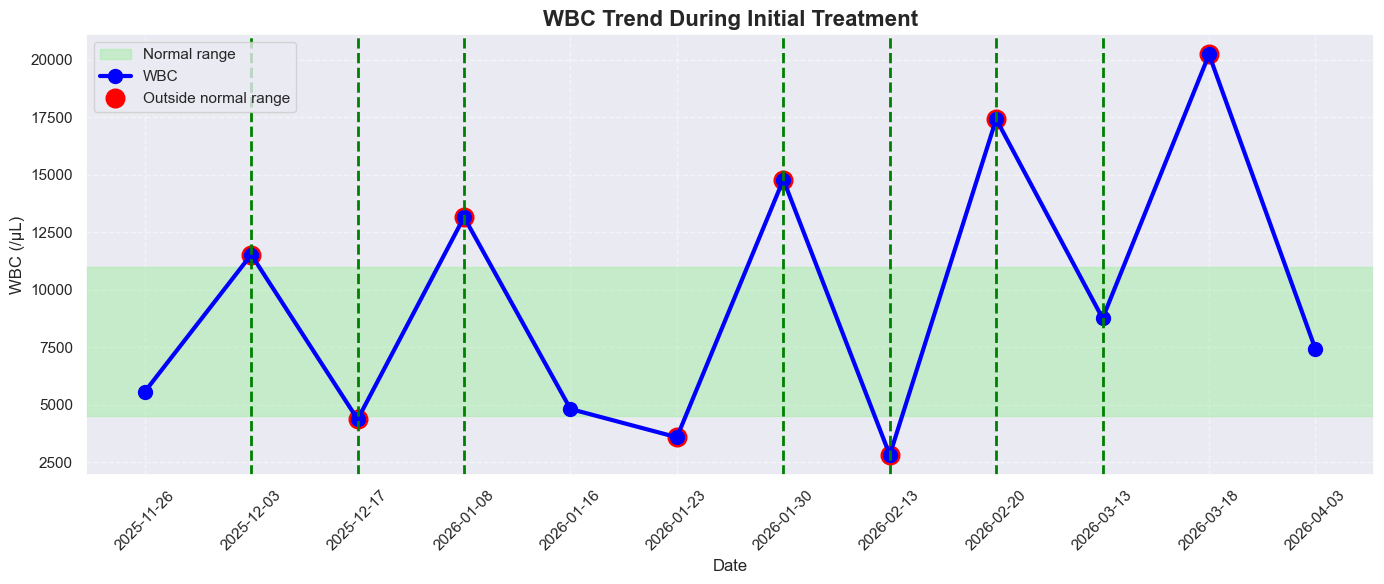

In [58]:
plt.figure(figsize=(14, 6))

# Normal WBC range
plt.axhspan(
    4500,
    11000,
    color='lightgreen',
    alpha=0.4,
    label='Normal range'
)

# WBC line
plt.plot(
    df['Date'],
    df['WBC (/uL)'],
    marker='o',
    color='blue',
    linewidth=3,
    markersize=10,
    label='WBC'
)

# Find abnormal WBC
abnormal_wbc = df[
    (df['WBC (/uL)'] < 4500) |
    (df['WBC (/uL)'] > 11000)
]

# Mark abnormal values
plt.scatter(
    abnormal_wbc['Date'],
    abnormal_wbc['WBC (/uL)'],
    color='red',
    s=180,
    label='Outside normal range'
)

# Find G-CSF dates
gcsf = df[df['G-CSF Intervention'] == True]

# Mark G-CSF
for date in gcsf['Date']:

    plt.axvline(
        date,
        color='green',
        linestyle='--',
        linewidth=2
    )

plt.title(
    'WBC Trend During Initial Treatment',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Date')
plt.ylabel('WBC (/µL)')

plt.grid(
    True,
    linestyle='--',
    alpha=0.5
)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [59]:
wbc_cell = df[['Date','Clinical Event / Phase','WBC (/uL)']].copy()

wbc_cell = wbc_cell[
    (wbc_cell['WBC (/uL)'] < 4500) ]

wbc_cell

,Date,Clinical Event / Phase,WBC (/uL)
3,2025-12-17,Chemo #2 Day 1,4360.0
6,2026-01-23,Amivantamab Ind #3,3580.0
8,2026-02-13,Inter-cycle Mid Check,2810.0


# Neutrophils + G-CSF

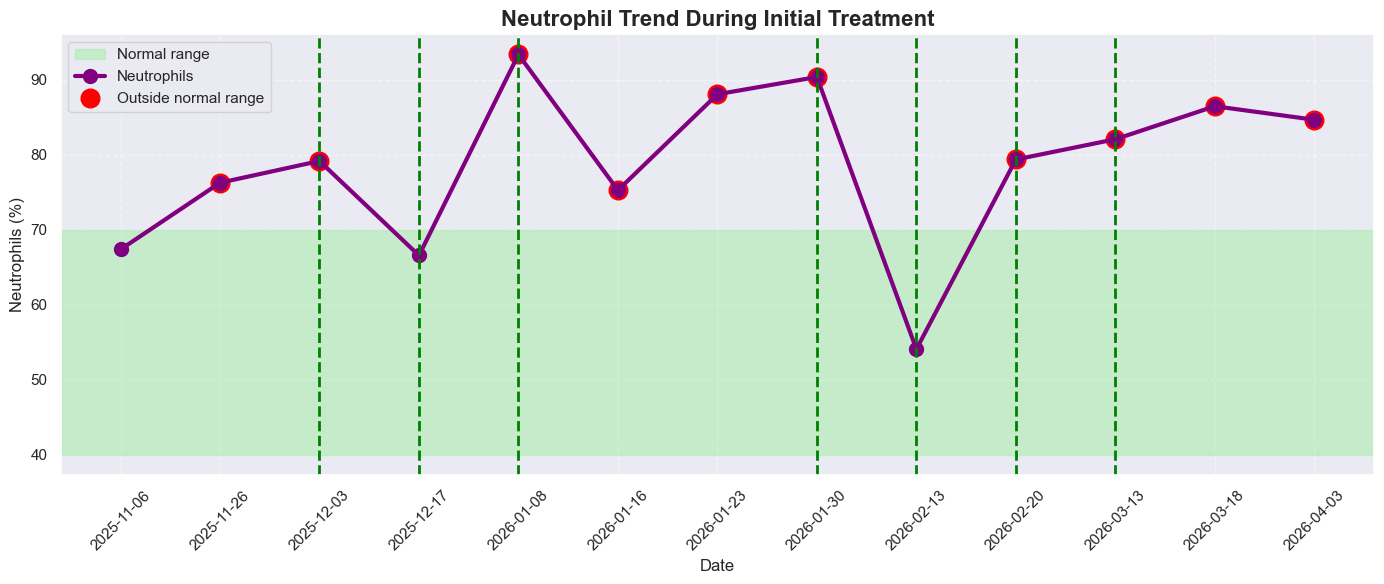

In [60]:
plt.figure(figsize=(14, 6))

# Normal neutrophil range
plt.axhspan(
    40,
    70,
    color='lightgreen',
    alpha=0.4,
    label='Normal range'
)

# Neutrophil trend
plt.plot(
    df['Date'],
    df['Neutrophils (%)'],
    marker='o',
    color='purple',
    linewidth=3,
    markersize=10,
    label='Neutrophils'
)

# Abnormal values
abnormal_neutrophils = df[
    (df['Neutrophils (%)'] < 40) |
    (df['Neutrophils (%)'] > 70)
]

plt.scatter(
    abnormal_neutrophils['Date'],
    abnormal_neutrophils['Neutrophils (%)'],
    color='red',
    s=180,
    label='Outside normal range'
)

# G-CSF dates
for date in gcsf['Date']:

    plt.axvline(
        date,
        color='green',
        linestyle='--',
        linewidth=2
    )

plt.title(
    'Neutrophil Trend During Initial Treatment',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Date')
plt.ylabel('Neutrophils (%)')

plt.grid(
    True,
    linestyle='--',
    alpha=0.5
)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [61]:
neutrophils_percent= df[['Date','Clinical Event / Phase', 'Clinical Symptoms / Notes','Pre-Medication','Neutrophils (%)']].copy()
neutrophils_percent = neutrophils_percent[
    (neutrophils_percent['Neutrophils (%)'] > 70)
]

neutrophils_percent


,Date,Clinical Event / Phase,Clinical Symptoms / Notes,Pre-Medication,Neutrophils (%)
1,2025-11-26,Chemo #1 Day 1,Cycle 1 Chemo baseline: normal marrow reserve ...,NaN,76.3
2,2025-12-03,Post Chemo #1 (Day +7),Post-Chemo Day +7 reaction: conjunctival eryth...,NaN,79.2
4,2026-01-08,Chemo #3 + Amivantamab Ind #1,Steroid Surge Phase (Decamax 8mg): profound de...,Decamax 16mg (2d),93.4
5,2026-01-16,Amivantamab Ind #2,Chemo Nadir Phase (Day +8 post-chemo): myelosu...,Decamax 16mg (2d),75.3
6,2026-01-23,Amivantamab Ind #3,Targeted Nadir & Cutaneous Phase: leukopenia (...,Decamax 16mg (2d),88.1
7,2026-01-30,Chemo #4 + Amivantamab Ind #4,Steroid Surge & Rebound Phase: post-booster re...,Decamax 16mg (2d),90.4
9,2026-02-20,Chemo #5 + Amivantamab Maint #1,Post-Rescue & Steroid Peak Phase: massive rebo...,Decamax 16mg (2d),79.4
10,2026-03-13,Chemo #6 + Amivantamab Maint #2,Chemo Maintenance Phase: steady marrow recover...,Decamax 16mg (2d),82.1
11,2026-03-18,Urological Evaluation (USG KUB),Acute Inflammatory / Sepsis-Response Phase: ma...,NaN,86.5
12,2026-04-03,Amivantamab Maint #3,Acute Renal Insult (AKI) Phase: sudden nephrot...,Decamax 16mg (2d),84.7


# Platelets + Platelet Support

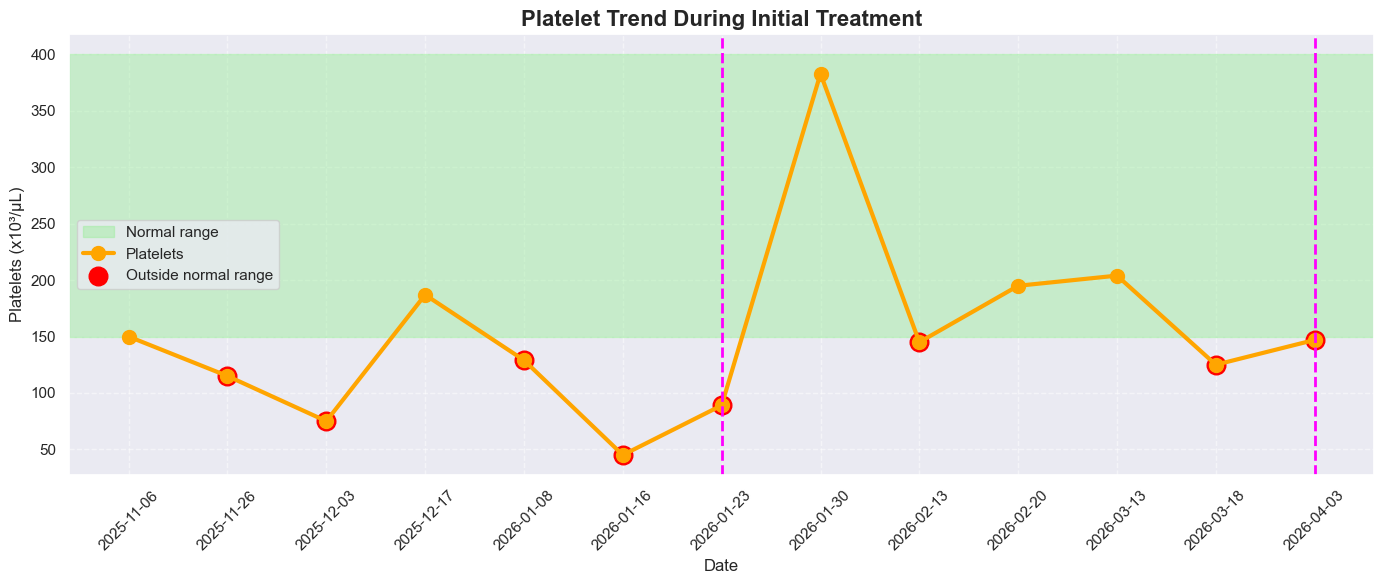

In [62]:
plt.figure(figsize=(14, 6))

# Normal platelet range
plt.axhspan(
    150,
    400,
    color='lightgreen',
    alpha=0.4,
    label='Normal range'
)

# Platelet trend
plt.plot(
    df['Date'],
    df['Platelets (x10^3/uL)'],
    marker='o',
    color='orange',
    linewidth=3,
    markersize=10,
    label='Platelets'
)

# Abnormal platelets
abnormal_platelets = df[
    (df['Platelets (x10^3/uL)'] < 150) |
    (df['Platelets (x10^3/uL)'] > 400)
]

plt.scatter(
    abnormal_platelets['Date'],
    abnormal_platelets['Platelets (x10^3/uL)'],
    color='red',
    s=180,
    label='Outside normal range'
)

# Platelet support dates
platelet_support = df[
    df['Platelets Support'] == True
]

for date in platelet_support['Date']:

    plt.axvline(
        date,
        color='magenta',
        linestyle='--',
        linewidth=2
    )

plt.title(
    'Platelet Trend During Initial Treatment',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Date')
plt.ylabel('Platelets (x10³/µL)')

plt.grid(
    True,
    linestyle='--',
    alpha=0.5
)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# Creatinine

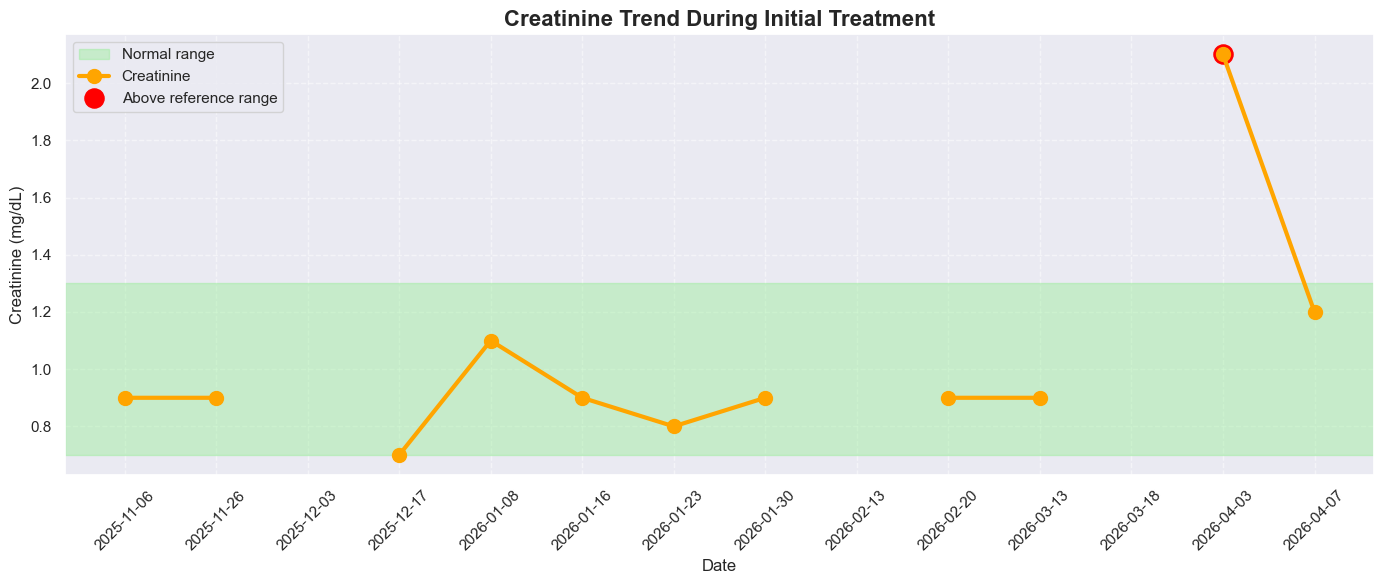

In [63]:
plt.figure(figsize=(14, 6))

# Normal range
plt.axhspan(
    0.7,
    1.3,
    color='lightgreen',
    alpha=0.4,
    label='Normal range'
)

# Creatinine
plt.plot(
    df['Date'],
    df['Creatinine (mg/dL)'],
    marker='o',
    color='orange',
    linewidth=3,
    markersize=10,
    label='Creatinine'
)

# High creatinine
high_creatinine = df[
    df['Creatinine (mg/dL)'] > 1.3
]

plt.scatter(
    high_creatinine['Date'],
    high_creatinine['Creatinine (mg/dL)'],
    color='red',
    s=190,
    label='Above reference range'
)

plt.title(
    'Creatinine Trend During Initial Treatment',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Date')
plt.ylabel('Creatinine (mg/dL)')

plt.grid(
    True,
    linestyle='--',
    alpha=0.5
)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [64]:
creatinine_value = df[
    ['Date','Clinical Event / Phase','Clinical Symptoms / Notes','Pre-Medication','Neutrophils (%)','WBC (/uL)',
     'Creatinine (mg/dL)']].copy()

creatinine_value = creatinine_value[creatinine_value['Creatinine (mg/dL)'] > 1.3]
creatinine_value

,Date,Clinical Event / Phase,Clinical Symptoms / Notes,Pre-Medication,Neutrophils (%),WBC (/uL),Creatinine (mg/dL)
12,2026-04-03,Amivantamab Maint #3,Acute Renal Insult (AKI) Phase: sudden nephrot...,Decamax 16mg (2d),84.7,7410.0,2.1


#  Observation

## 1. WBC Response

WBC counts showed periods of decline during several chemotherapy-related phases.

Lower WBC values were observed during treatment nadirs, while G-CSF interventions were documented during periods of reduced WBC/neutrophil counts.

Following supportive treatment and steroid-associated phases, marked increases in WBC and neutrophils were observed.

**Observation:**  
The timeline shows a pattern of **WBC decline → supportive intervention → subsequent rebound** at several points.

---

## 2. Neutrophil Response

Neutrophil counts showed a noticeable increase during the steroid pre-medication phase.

A marked neutrophil increase was observed with neutrophils reaching **93.4% and ANC 12,282/µL** during the documented steroid surge phase.

Later, periods of lower neutrophil counts were observed, including a documented nadir with **ANC 1,520/µL**, followed by G-CSF intervention and subsequent rebound.

A later increase in neutrophils also coincided with a documented infectious/inflammatory episode.

**Observation:**  
The data shows substantial movement in neutrophil counts across **steroid-associated phases, chemotherapy nadirs, supportive treatment, and later clinical events**.

---

## 3. Platelet Response

Platelet counts showed fluctuations during chemotherapy.

The lowest documented platelet value was approximately **45k/µL**, during which platelet support was documented.

A subsequent increase in platelet count was observed, including a later platelet value of approximately **383k/µL**.

**Observation:**  
The platelet timeline demonstrates a pattern of **decline during treatment → supportive intervention → subsequent recovery/rebound**.

---

## 4. Creatinine Response

Creatinine remained within the selected reference range during the earlier treatment period.

A later increase to **2.10 mg/dL** was observed. This occurred alongside documented clinical findings including **fever, chills, rigors, BP fluctuation, swollen feet, limping, and swollen eyelids**.

During this period, Carboplatin was omitted.

In the subsequent measurement, creatinine decreased to **1.21 mg/dL**, while the clinical notes documented improvement in fever and pedal edema.

**Observation:**  
The creatinine timeline shows a clear **increase → clinical symptoms/treatment change → subsequent improvement** pattern.

---

# Additional Clinical Observations

The laboratory trends were reviewed alongside the clinical notes rather than being analyzed independently.

Several additional observations appeared in the timeline:

- Amivantamab administration was accompanied by documented **pre-medication**.
- A marked neutrophil increase was observed during the steroid-associated phase.
- Blood-pressure fluctuation was documented around the initial amivantamab induction.
- Voice changes and other mucocutaneous symptoms were documented during the targeted-treatment period.
- Urinary symptoms and blood in urine were documented later in the treatment timeline.
- Ultrasound evaluation documented **prostate enlargement**.
- PSA later increased to **7.2 ng/mL**.
- A subsequent creatinine increase occurred alongside several systemic and urinary/clinical findings.

---

# Overall Observation

The analysis shows that the laboratory values did not change independently of the treatment timeline.

Across the initial treatment period, there were observable changes in:

**WBC → Neutrophils → Platelets → Creatinine**

These changes occurred alongside:

**Chemotherapy → Amivantamab → Steroid pre-medication → G-CSF → Platelet support → Clinical symptoms → Treatment modifications**

The most useful analytical pattern was therefore:

### Laboratory Value → Clinical Event/Symptom → Intervention → Subsequent Change

This approach provides more context than looking at individual laboratory values alone.

---

# Key Finding Leading to the Next Stage

The later part of the timeline contains several findings occurring around the period of changing renal-function measurements, including urinary symptoms, blood in urine, prostate enlargement, increased PSA, infection/inflammatory symptoms, and the subsequent rise in creatinine.

These findings raise an important **research question for the next stage**:

> **What factors may have contributed to the subsequent change in renal function?**

The next stage will therefore investigate the relationship between:

**Urinary findings + infection/inflammation + treatment exposure + clinical symptoms + creatinine/eGFR**

This project does not treat the observed associations as proof of causation. The purpose of this stage is to identify patterns in the clinical data and use those patterns to define the next analytical question.